**姓名：黄海鸿    学号：3123009487    选题：手写数字识别**  

### 1）算法以及数据库导入，选择3种分类算法：SVM，RandomForest，KNeighbors

In [1]:
# 基础库
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 数据集

from sklearn.datasets import load_digits

# 数据预处理
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# 特征提取
from sklearn.decomposition import PCA

# 分类器
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# 评估指标
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 忽略警告（可选）
import warnings
warnings.filterwarnings('ignore')

### 2）数据加载，可视化一些数据样本

数据形状: (1797, 64)
标签形状: (1797,)


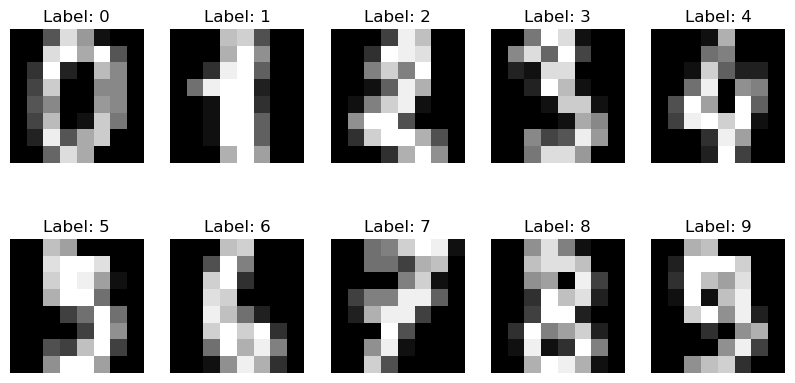

In [2]:
# 加载数据
digits = load_digits()
X, y = digits.data, digits.target

# 查看数据形状
print(f"数据形状: {X.shape}") # (1797, 64) 表示有1797个样本，每个样本有8x8=64个特征（像素）
print(f"标签形状: {y.shape}")

# 可视化一些样本
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(8, 8), cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.show()

### 3）划分训练集以及测试集，分别占比80%和20%

In [3]:
# 划分训练集和测试集（80%训练，20%测试）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 数据标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"训练集大小: {X_train_scaled.shape}")
print(f"测试集大小: {X_test_scaled.shape}")

训练集大小: (1437, 64)
测试集大小: (360, 64)


### 4）使用PCA进行特征提取，保留95%信息

PCA降维后的特征数量: 40


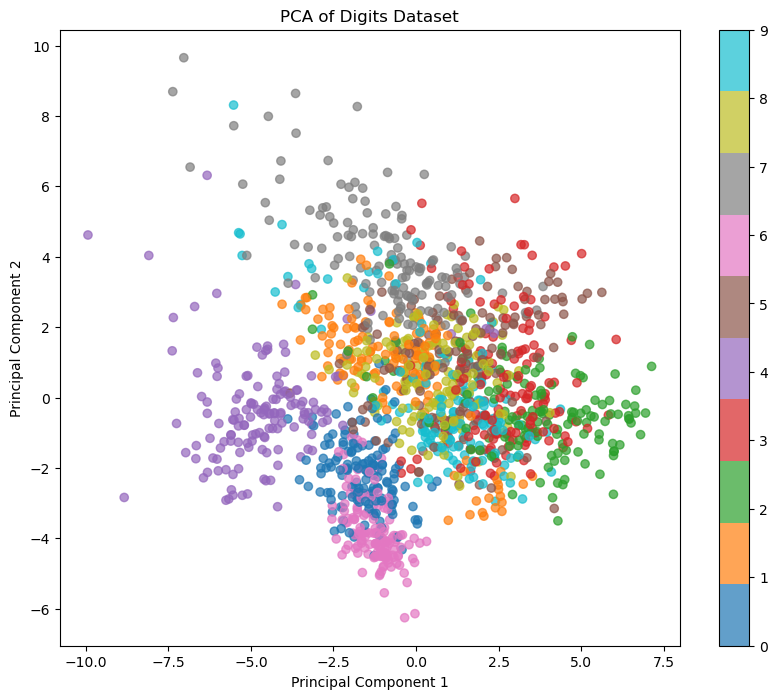

In [4]:
# 使用PCA降维，保留95%的方差信息
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA降维后的特征数量: {X_train_pca.shape[1]}")

# 可视化PCA降维后的前两个主成分
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='tab10', alpha=0.7)
plt.colorbar(scatter)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Digits Dataset')
plt.show()

### 5）算法选择以及超参选择

In [5]:
models = {
    'SVM': {
        'model': SVC(random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'gamma': ['scale', 'auto', 0.01, 0.001],
            'kernel': ['rbf', 'linear']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5]
        }
    },
    'K-NN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7],
            'weights': ['uniform', 'distance']
        }
    }
}

### 6）使用5级交叉验证，使用网络搜索进行超参调整

In [6]:
# 使用GridSearchCV进行超参数调优并记录结果
best_models = {}
best_scores = {}

print("开始超参数调优...")
for name, config in models.items():
    print(f"\n--- 正在调优 {name} ---")
    gs = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        cv=5, # 5折交叉验证
        scoring='accuracy',
        n_jobs=-1 # 使用所有可用的CPU核心
    )
    gs.fit(X_train_pca, y_train)
    
    best_models[name] = gs.best_estimator_
    best_scores[name] = gs.best_score_
    
    print(f"最佳参数: {gs.best_params_}")
    print(f"最佳交叉验证准确率: {gs.best_score_:.4f}")

# 比较不同模型的最佳交叉验证分数
print("\n=== 模型比较 ===")
for name in best_scores:
    print(f"{name}: {best_scores[name]:.4f}")

开始超参数调优...

--- 正在调优 SVM ---


最佳参数: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
最佳交叉验证准确率: 0.9819

--- 正在调优 Random Forest ---
最佳参数: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
最佳交叉验证准确率: 0.9638

--- 正在调优 K-NN ---
最佳参数: {'n_neighbors': 5, 'weights': 'distance'}
最佳交叉验证准确率: 0.9742

=== 模型比较 ===
SVM: 0.9819
Random Forest: 0.9638
K-NN: 0.9742


### 7）获得表现最好的模型，并打印分类报告

In [7]:
# 选择交叉验证中表现最好的模型
best_model_name = max(best_scores, key=best_scores.get)
best_model = best_models[best_model_name]

print(f"在测试集上评估最佳模型: {best_model_name}")

# 在测试集上进行预测
y_pred = best_model.predict(X_test_pca)

# 计算测试集准确率
test_accuracy = accuracy_score(y_test, y_pred)
print(f"测试集准确率: {test_accuracy:.4f}")

# 详细的分类报告
print("\n分类报告:")
print(classification_report(y_test, y_pred))

在测试集上评估最佳模型: SVM
测试集准确率: 0.9778

分类报告:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      0.97      0.96        36
           2       0.97      1.00      0.99        35
           3       1.00      1.00      1.00        37
           4       0.95      0.97      0.96        36
           5       1.00      1.00      1.00        37
           6       0.97      1.00      0.99        36
           7       0.95      0.97      0.96        36
           8       1.00      0.91      0.96        35
           9       1.00      0.94      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



### 8）混淆矩阵绘制

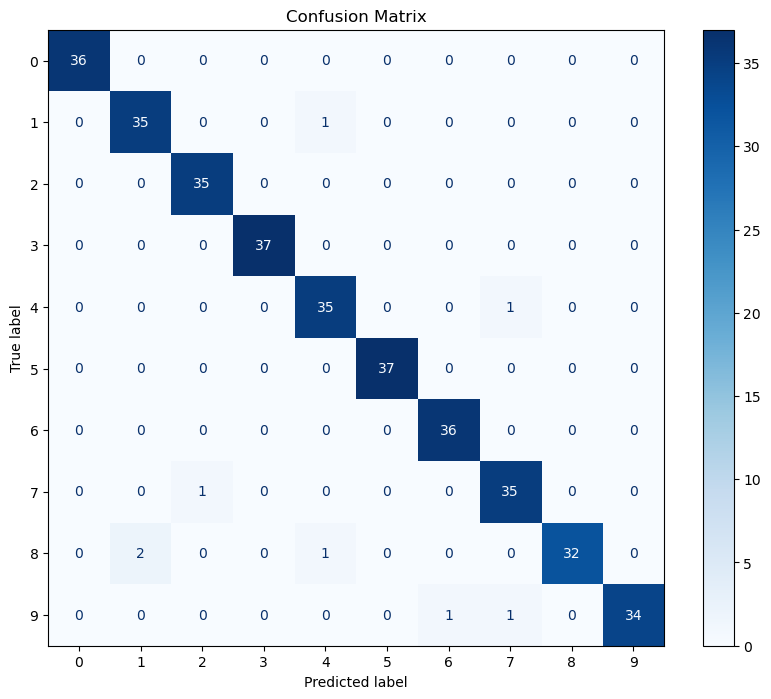

In [8]:
# 绘制混淆矩阵
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=digits.target_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

### 9）显示结果

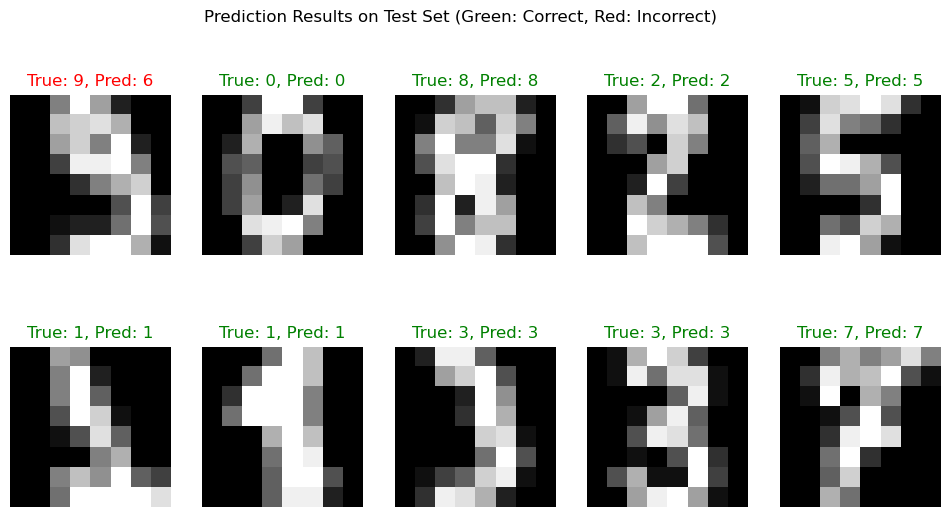

In [9]:
n_samples_to_show = 10
indices = np.random.choice(len(X_test), n_samples_to_show)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, (ax, idx) in enumerate(zip(axes.flat, indices)):
    ax.imshow(X_test[idx].reshape(8, 8), cmap='gray')
    ax.set_title(f"True: {y_test[idx]}, Pred: {y_pred[idx]}", 
                 color='green' if y_test[idx] == y_pred[idx] else 'red')
    ax.axis('off')
plt.suptitle('Prediction Results on Test Set (Green: Correct, Red: Incorrect)')
plt.show()